In [47]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

URL = Path("../data/raw/california_housing.csv")

def load_housing_data(URL):
    return pd.read_csv(URL)

housing_data = load_housing_data(URL)

housing_data.head(10)
housing_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## Splitting the data into training set and testing set

In [48]:
X = housing_data.drop("median_house_value",axis=1)
y = housing_data["median_house_value"]

In [ ]:
housing_data['rooms_per_house'] = housing_data['total_rooms'] / housing_data['households']
housing_data['bedrooms_per_house'] = housing_data['total_bedrooms'] / housing_data['households']
housing_data['people_per_house'] = housing_data['total_rooms'] / housing_data['households']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Getting insights from the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
0         129.0
1        1106.0
2         190.0
3         235.0
4         280.0
          ...  
20635     374.0
20636     150.0
20637     485.0
20638     409.0
20639     616.0
Name: total_bedrooms, Length: 20640, dtype: float64


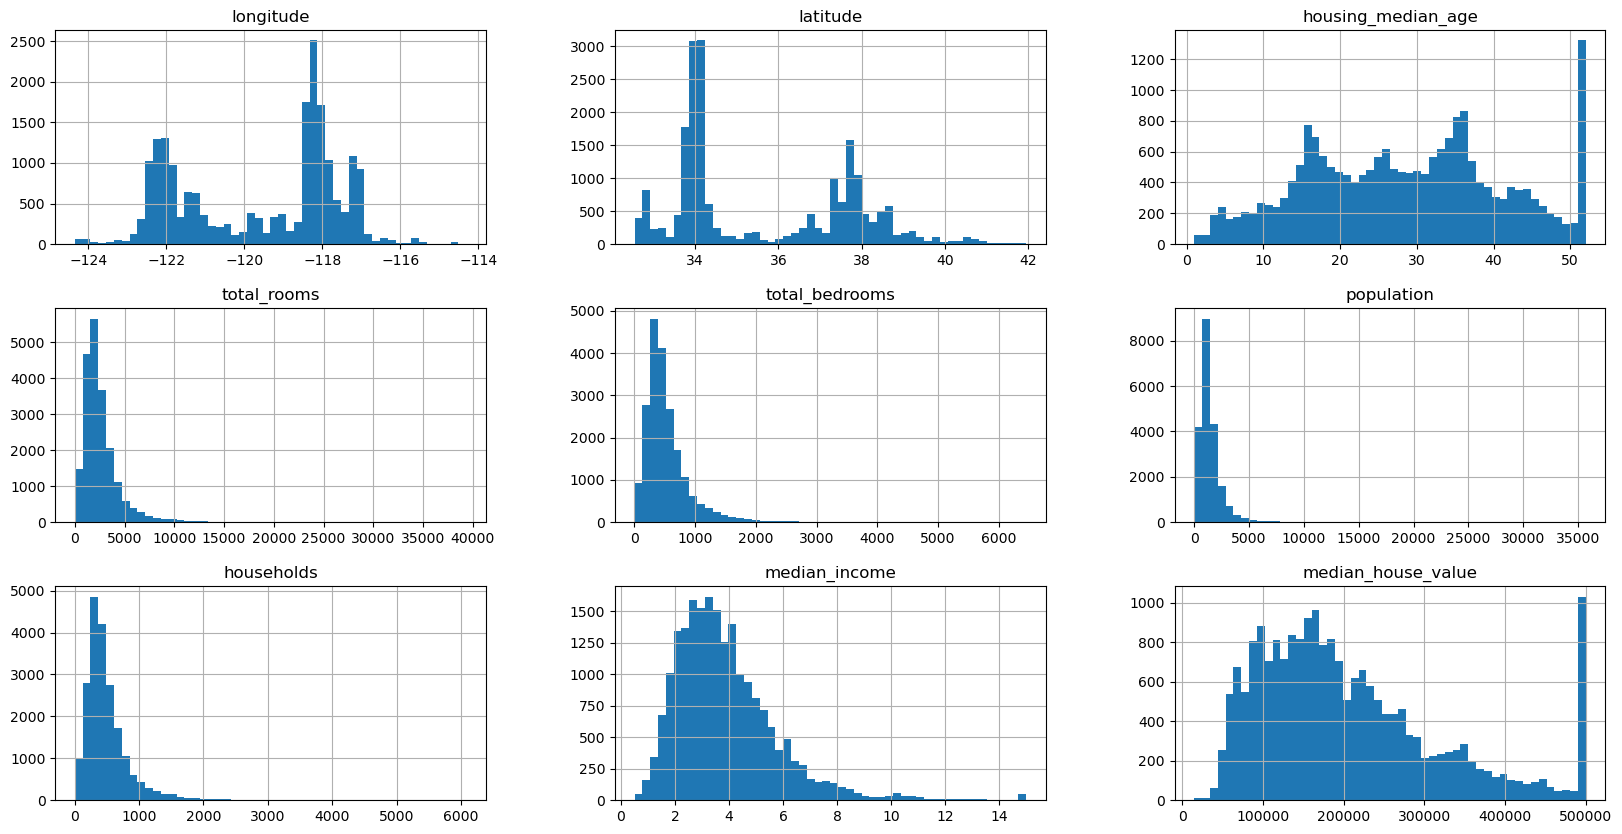

In [ ]:
housing_data.head()
housing_data.info()
housing_data.describe()
housing_data.hist(bins=50,figsize=(20,10))
print(housing_data[["total_bedrooms"]])

## Correlation Analysis

In [60]:
# corr_matrix = housing_data.corr()
housing_data.info()
housing_data_eda = housing_data.copy()
housing_data_eda = pd.get_dummies(housing_data,columns=['ocean_proximity'])

housing_data_eda["bedrooms_per_house"] = housing_data_eda["total_bedrooms"] / housing_data_eda["households"]
housing_data_eda["rooms_per_house"] = housing_data_eda["total_rooms"] / housing_data_eda["households"]
housing_data_eda["people_per_house"] = housing_data_eda["population"] / housing_data_eda["households"]


corr_matrix = housing_data_eda.corr()
# corr_matrix.info()
corr_matrix["median_house_value"].sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


median_house_value            1.000000
median_income                 0.688075
ocean_proximity_<1H OCEAN     0.256617
ocean_proximity_NEAR BAY      0.160284
rooms_per_house               0.151948
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049686
ocean_proximity_ISLAND        0.023416
people_per_house             -0.023737
population                   -0.024650
longitude                    -0.045967
bedrooms_per_house           -0.046739
latitude                     -0.144160
ocean_proximity_INLAND       -0.484859
Name: median_house_value, dtype: float64

## Creating machine learning pipeline